In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

import schwingerModel as sim

In [2]:
totalSteps = 100

a = 1
dimx = 8
dimt = 16

R = 10/(32*16) #ratio that we want to keep constant while taking continuum limit

beta = 2.0

# m = 0.2 *np.sqrt(10/beta)
m=1

In [3]:
models = []

subSteps = (np.geomspace(10,100,10)).astype(int)

models = Parallel(n_jobs=-1)(delayed(sim.schwingerModel)(metroSteps=totalSteps,beta=beta,dimx=dimx,dimt=dimt,aSpacing=a,fMass=m,cgRtol=1e-5,numSubSteps=subSteps[i],tqdmPosition=i) for i in range(len(subSteps)))






  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]


  0%|          | 0/100 [00:00<?, ?it/s]



  0%|          | 0/100 [00:00<?, ?it/s]





  0%|          | 0/100 [00:00<?, ?it/s]








  0%|          | 0/100 [00:00<?, ?it/s]







  0%|          | 0/100 [00:00<?, ?it/s]






  0%|          | 0/100 [00:00<?, ?it/s]

  3%|▎         | 3/100 [00:00<00:03, 29.48it/s]



  5%|▌         | 5/100 [00:00<00:02, 42.89it/s]





  1%|          | 1/100 [00:00<00:10,  9.02it/s]


  3%|▎         | 3/100 [00:00<00:04, 23.65it/s]




  2%|▏         | 2/100 [00:00<00:06, 15.34it/s]







  1%|          | 1/100 [00:00<00:13,  7.43it/s]






  1%|          | 1/100 [00:00<00:13,  7.28it/s]

  6%|▌         | 6/100 [00:00<00:03, 29.62it/s]








  1%|          | 1/100 [00:00<00:17,  5.59it/s]



  8%|▊         | 8/100 [00:00<00:02, 36.88it/s]





 10%|█         | 10/100 [00:00<00:02, 43.08it/s][A


  6%|▌         | 6/100 [00:00<00:03, 23.77it/s]




  4%|▍       

In [4]:
aFracs = []
for mod in models:
    aFrac = sim.analysis.acceptanceFraction(mod)
    aFracs.append(aFrac)
aFrac = np.array(aFrac)

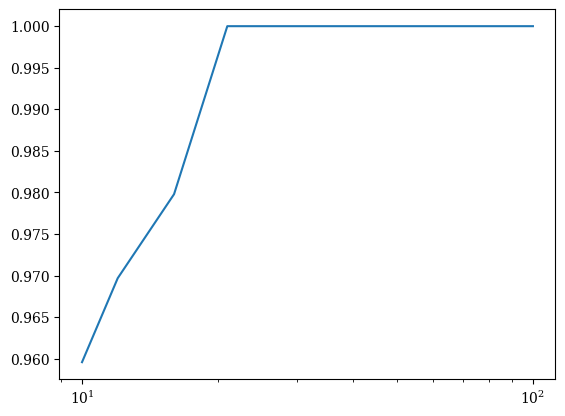

In [5]:
plt.semilogx(subSteps,aFracs)

In [14]:
subSteps[-7]

np.int64(21)

In [13]:
sim.analysis.acceptanceFraction(models[-7])

np.float64(0.98989898989899)

In [62]:
correl = sim.distillation.correlStats(models[-1],burnIn=5,autocorrSkip=3)

configs:   0%|          | 0/32 [00:00<?, ?it/s]

In [63]:
sim.distillation.correlMassExtract(correl,fitT=[4,12],diagCov=True)

array([0.19196894, 0.00045527])